## nb29 — CD5 Trajectory: Award vs. Control (±5 Years)

Speed optimisations (all 3 applied):
- **A** Pre-filter: skip papers with cited_by_count == 0 (bulk fetch, ~287 API calls total)
- **B** Parallel: ThreadPoolExecutor with 10 workers + shared rate limiter
- **C** Citer cap: sample max 50 citers per paper; bulk-fetch their refs in batches of 100

Expected combined speedup: ~20-30x vs original.

In [2]:
import pandas as pd
import numpy as np
import requests
import time
import random
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

ROOT    = Path('..')
CD_DIR  = ROOT / 'data' / 'cd_trajectory'
FIG_DIR = ROOT / 'data' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

API_KEY     = 'A08hCjeUoeVKA9toVsfCpF'
N_WORKERS   = 10       # Opt B: parallel workers
MAX_CITERS  = 50       # Opt C: cap citers per paper
RATE_LOCK   = threading.Lock()
LAST_CALL   = [0.0]
MIN_DELAY   = 0.08     # ~12 req/s across all threads (safe with API key)

In [4]:
panel = pd.read_csv(CD_DIR / 'author_papers_panel.csv')
print(panel.shape)
print(panel.groupby('group')['author_id'].nunique())
unique_papers = panel[['paper_id', 'paper_year']].drop_duplicates().reset_index(drop=True)
print(f'Unique papers before filter: {len(unique_papers)}')

(30759, 6)
group
award      602
control    188
Name: author_id, dtype: int64
Unique papers before filter: 28681


In [5]:
# --- Opt A: Bulk-fetch cited_by_count, drop uncited ---
FILTER_CP = CD_DIR / 'papers_citation_counts.csv'

def fetch_cit_counts_batch(ids):
    r = requests.get('https://api.openalex.org/works', params={
        'filter': f"openalex_id:{'|'.join(ids)}",
        'per-page': 100, 'select': 'id,cited_by_count', 'api_key': API_KEY,
    }, timeout=20)
    if r.status_code != 200: return []
    return [{'paper_id': w['id'].split('/')[-1], 'cited_by_count': w['cited_by_count']}
            for w in r.json().get('results', [])]

if FILTER_CP.exists():
    cit_df = pd.read_csv(FILTER_CP)
    done_ids = set(cit_df['paper_id'])
else:
    cit_df, done_ids = pd.DataFrame(), set()

todo_ids = unique_papers[~unique_papers['paper_id'].isin(done_ids)]['paper_id'].tolist()
print(f'Fetching citation counts for {len(todo_ids)} papers in batches of 100...')

new_rows = []
for i in range(0, len(todo_ids), 100):
    new_rows.extend(fetch_cit_counts_batch(todo_ids[i:i+100]))
    if (i // 100 + 1) % 20 == 0:
        cit_df = pd.concat([cit_df, pd.DataFrame(new_rows)], ignore_index=True)
        cit_df.to_csv(FILTER_CP, index=False)
        new_rows = []
        print(f'  {i+100}/{len(todo_ids)} saved')
    time.sleep(0.2)

cit_df = pd.concat([cit_df, pd.DataFrame(new_rows)], ignore_index=True)
cit_df.to_csv(FILTER_CP, index=False)

unique_papers = unique_papers.merge(cit_df, on='paper_id', how='left')
before = len(unique_papers)
unique_papers = unique_papers[unique_papers['cited_by_count'].fillna(0) > 0].reset_index(drop=True)
print(f'Kept {len(unique_papers)} cited papers (dropped {before - len(unique_papers)} uncited)')

Fetching citation counts for 0 papers in batches of 100...
Kept 23690 cited papers (dropped 4991 uncited)


In [6]:
# --- Shared rate-limited GET ---
def _get(url, params):
    with RATE_LOCK:
        gap = MIN_DELAY - (time.time() - LAST_CALL[0])
        if gap > 0: time.sleep(gap)
        LAST_CALL[0] = time.time()
    return requests.get(url, params=params, timeout=15)

def get_references(work_id):
    r = _get(f'https://api.openalex.org/works/{work_id}', {'api_key': API_KEY})
    if r.status_code != 200: return []
    return [x.split('/')[-1] for x in r.json().get('referenced_works', [])]

def get_citations(work_id, focal_year, window=5):
    citers, cursor = [], '*'
    while True:
        r = _get('https://api.openalex.org/works', {
            'filter': f'cites:{work_id},publication_year:{focal_year}-{focal_year+window}',
            'per-page': 200, 'select': 'id', 'cursor': cursor, 'api_key': API_KEY,
        })
        if r.status_code != 200: break
        data = r.json()
        results = data.get('results', [])
        citers.extend([w['id'].split('/')[-1] for w in results])
        cursor = data.get('meta', {}).get('next_cursor')
        if not cursor or not results: break
    return citers

# --- Opt C: Bulk-fetch refs for up to 100 citers in one API call ---
def get_refs_bulk(citer_ids):
    """Returns dict {citer_id: set(ref_ids)} for a batch of up to 100 citers."""
    r = _get('https://api.openalex.org/works', {
        'filter': f"openalex_id:{'|'.join(citer_ids)}",
        'per-page': 100,
        'select': 'id,referenced_works',
        'api_key': API_KEY,
    })
    if r.status_code != 200: return {}
    out = {}
    for w in r.json().get('results', []):
        cid = w['id'].split('/')[-1]
        out[cid] = set(ref.split('/')[-1] for ref in w.get('referenced_works', []))
    return out

def compute_cd5(work_id, focal_year):
    focal_refs = set(get_references(work_id))
    all_citers = get_citations(work_id, focal_year)
    if not all_citers: return np.nan, 0, 0

    # Opt C: cap at MAX_CITERS (random sample if more)
    if len(all_citers) > MAX_CITERS:
        all_citers = random.sample(all_citers, MAX_CITERS)

    # Bulk-fetch refs in batches of 100
    citer_refs_map = {}
    for i in range(0, len(all_citers), 100):
        citer_refs_map.update(get_refs_bulk(all_citers[i:i+100]))

    ni, nj = 0, 0
    for cid in all_citers:
        refs = citer_refs_map.get(cid, set())
        if refs & focal_refs: nj += 1
        else: ni += 1
    total = ni + nj
    return (ni - nj) / total if total > 0 else np.nan, ni, nj

def score_paper(row):
    cd, ni, nj = compute_cd5(row['paper_id'], int(row['paper_year']))
    return {'paper_id': row['paper_id'], 'paper_year': int(row['paper_year']),
            'cd5': cd, 'ni': ni, 'nj': nj}

In [7]:
# --- Opt B: Parallel scoring ---
CHECKPOINT = CD_DIR / 'paper_cd5_scores.csv'

if CHECKPOINT.exists():
    done_cd  = pd.read_csv(CHECKPOINT)
    done_ids = set(done_cd['paper_id'].unique())
    print(f'Resuming — {len(done_ids)} papers already scored')
else:
    done_cd, done_ids = pd.DataFrame(), set()

todo_list = unique_papers[~unique_papers['paper_id'].isin(done_ids)].to_dict('records')
print(f'Remaining: {len(todo_list)} papers | {N_WORKERS} workers | citer cap: {MAX_CITERS}')

buf, completed = [], 0
with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = {ex.submit(score_paper, row): row for row in todo_list}
    for f in as_completed(futures):
        try:
            buf.append(f.result())
        except Exception:
            r = futures[f]
            buf.append({'paper_id': r['paper_id'], 'paper_year': r['paper_year'],
                        'cd5': np.nan, 'ni': 0, 'nj': 0})
        completed += 1
        if completed % 50 == 0 or completed == len(todo_list):
            done_cd = pd.concat([done_cd, pd.DataFrame(buf)], ignore_index=True)
            done_cd.to_csv(CHECKPOINT, index=False)
            buf = []
            print(f'[{completed}/{len(todo_list)}] saved — {done_cd["cd5"].notna().sum()} valid')

print('Done!')

Remaining: 23690 papers | 10 workers | citer cap: 50
[50/23690] saved — 50 valid
[100/23690] saved — 99 valid
[150/23690] saved — 147 valid
[200/23690] saved — 197 valid
[250/23690] saved — 246 valid
[300/23690] saved — 294 valid
[350/23690] saved — 344 valid
[400/23690] saved — 394 valid
[450/23690] saved — 444 valid
[500/23690] saved — 493 valid
[550/23690] saved — 542 valid
[600/23690] saved — 592 valid
[650/23690] saved — 642 valid
[700/23690] saved — 692 valid
[750/23690] saved — 742 valid
[800/23690] saved — 792 valid
[850/23690] saved — 841 valid
[900/23690] saved — 890 valid
[950/23690] saved — 940 valid
[1000/23690] saved — 988 valid
[1050/23690] saved — 1038 valid
[1100/23690] saved — 1088 valid
[1150/23690] saved — 1138 valid
[1200/23690] saved — 1186 valid
[1250/23690] saved — 1236 valid
[1300/23690] saved — 1286 valid
[1350/23690] saved — 1335 valid
[1400/23690] saved — 1385 valid
[1450/23690] saved — 1435 valid
[1500/23690] saved — 1485 valid
[1550/23690] saved — 1535 val

In [8]:
cd_scores = pd.read_csv(CD_DIR / 'paper_cd5_scores.csv')
panel_cd  = panel.merge(cd_scores[['paper_id', 'cd5']], on='paper_id', how='left')
print(f'Panel rows: {len(panel_cd)}')
print(f"CD5 coverage: {panel_cd['cd5'].notna().mean():.1%}")
panel_cd.head()

Panel rows: 30759
CD5 coverage: 80.4%


,author_id,group,award_year,paper_id,paper_year,relative_year,cd5
0,https://openalex.org/A5014823249,award,2018,W2407964224,2014,-4,-0.636364
1,https://openalex.org/A5014823249,award,2018,W2788603415,2018,0,-0.444444
2,https://openalex.org/A5014823249,award,2018,W2759170062,2017,-1,-0.333333
3,https://openalex.org/A5014823249,award,2018,W2965050397,2019,1,-0.882353
4,https://openalex.org/A5014823249,award,2018,W3098410977,2020,2,1.000000


In [9]:
author_year = (
    panel_cd.dropna(subset=['cd5'])
    .groupby(['author_id', 'group', 'award_year', 'relative_year'])['cd5']
    .mean().reset_index()
)
print(author_year.shape)
author_year.head()

(5176, 5)


,author_id,group,award_year,relative_year,cd5
0,https://openalex.org/A5000009841,award,2014,-1,-0.500000
1,https://openalex.org/A5000009841,award,2014,0,-0.840000
2,https://openalex.org/A5000009841,award,2014,2,-0.633103
3,https://openalex.org/A5000009841,award,2014,3,0.057778
4,https://openalex.org/A5000009841,award,2014,4,-0.320000


In [10]:
def ci95(x):
    n = x.notna().sum()
    if n < 2: return np.nan
    return stats.sem(x.dropna()) * stats.t.ppf(0.975, df=n-1)

traj = (
    author_year.groupby(['group', 'relative_year'])['cd5']
    .agg(mean='mean', ci=ci95, n='count').reset_index()
)
traj = traj[traj['relative_year'].between(-5, 5)]
print(traj)

      group  relative_year      mean        ci    n
0     award             -5 -0.310342  0.136197   75
1     award             -4 -0.338544  0.092492  152
2     award             -3 -0.324065  0.078348  227
3     award             -2 -0.342974  0.060013  297
4     award             -1 -0.378378  0.050933  363
5     award              0 -0.354655  0.032766  591
6     award              1 -0.345824  0.044535  428
7     award              2 -0.309162  0.044001  420
8     award              3 -0.283133  0.048687  395
9     award              4 -0.288217  0.053400  336
10    award              5 -0.264983  0.051284  333
11  control             -5 -0.252320  0.092097  104
12  control             -4 -0.259388  0.101783  112
13  control             -3 -0.324493  0.090694  122
14  control             -2 -0.321793  0.080223  130
15  control             -1 -0.259386  0.080403  137
16  control              0 -0.308585  0.068483  151
17  control              1 -0.308756  0.062044  146
18  control 

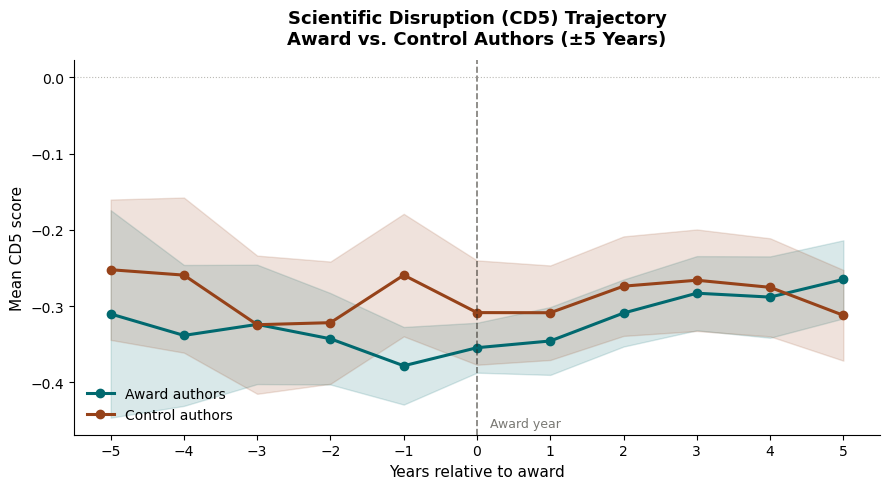

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'award': '#01696f', 'control': '#964219'}
labels = {'award': 'Award authors', 'control': 'Control authors'}

for grp, gdf in traj.groupby('group'):
    gdf = gdf.sort_values('relative_year')
    ax.plot(gdf['relative_year'], gdf['mean'], marker='o', lw=2.2,
            color=colors[grp], label=labels[grp])
    ax.fill_between(gdf['relative_year'],
                    gdf['mean'] - gdf['ci'], gdf['mean'] + gdf['ci'],
                    alpha=0.15, color=colors[grp])

ax.axvline(0, color='#28251d', lw=1.2, ls='--', alpha=0.6)
ax.axhline(0, color='#bab9b4', lw=0.8, ls=':')
ax.text(0.18, ax.get_ylim()[0] + 0.01, 'Award year', fontsize=9, color='#7a7974')
ax.set_xlabel('Years relative to award', fontsize=11)
ax.set_ylabel('Mean CD5 score', fontsize=11)
ax.set_title('Scientific Disruption (CD5) Trajectory\nAward vs. Control Authors (±5 Years)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(range(-5, 6))
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(FIG_DIR / 'cd5_trajectory_award_vs_control.png', dpi=200, bbox_inches='tight')
plt.show()

In [12]:
reg_df = author_year.copy()
reg_df['treated'] = (reg_df['group'] == 'award').astype(int)
reg_df['post']    = (reg_df['relative_year'] >= 0).astype(int)
reg_df['year_fe'] = reg_df['award_year'].astype(str)

model = smf.ols('cd5 ~ treated * post + C(relative_year) + C(year_fe)',
                data=reg_df.dropna(subset=['cd5'])).fit(cov_type='HC3')
print(model.summary().tables[1])
did_coef = model.params.get('treated:post', np.nan)
did_pval = model.pvalues.get('treated:post', np.nan)
print(f'\nDiD (treated x post): {did_coef:.4f}  p={did_pval:.4f}')

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.1518      0.070     -2.183      0.029      -0.288      -0.016
C(relative_year)[T.-4]    -0.0219      0.053     -0.412      0.680      -0.126       0.082
C(relative_year)[T.-3]    -0.0321      0.050     -0.637      0.524      -0.131       0.067
C(relative_year)[T.-2]    -0.0424      0.048     -0.891      0.373      -0.136       0.051
C(relative_year)[T.-1]    -0.0513      0.047     -1.099      0.272      -0.143       0.040
C(relative_year)[T.0]     -0.0465      0.016     -2.909      0.004      -0.078      -0.015
C(relative_year)[T.1]     -0.0379      0.018     -2.092      0.036      -0.073      -0.002
C(relative_year)[T.2]     -0.0011      0.018     -0.064      0.949      -0.036       0.034
C(relative_year)[T.3]      0.0195      0.019      1.032      0.302      -0.018       0.057

c:\Users\sla99\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 31, but rank is 30
  warnings.warn('covariance of constraints does not have full '


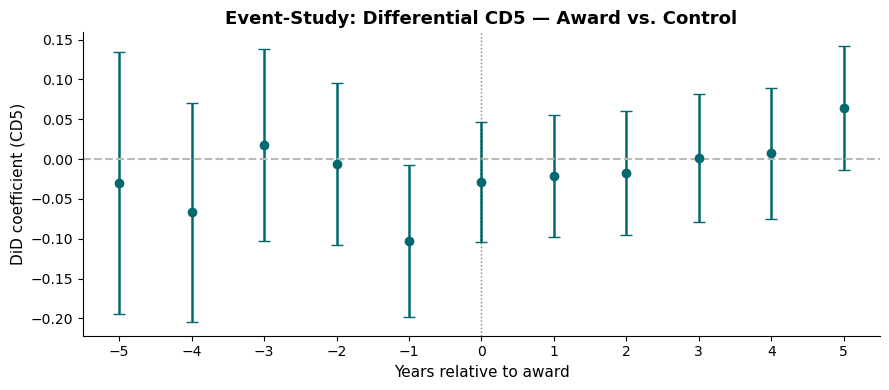

In [17]:
import re

reg_df['rel_str'] = reg_df['relative_year'].astype(str)
es_model = smf.ols('cd5 ~ treated:C(rel_str) + C(rel_str) + C(year_fe)',
                   data=reg_df.dropna(subset=['cd5'])).fit(cov_type='HC3')

es_coefs = {k: v for k, v in es_model.params.items() if 'treated:C(rel_str)' in k}
es_ses   = {k: v for k, v in es_model.bse.items()   if 'treated:C(rel_str)' in k}

es_df = pd.DataFrame({
    'rel_year': [int(re.search(r'\[(-?\d+)\]', k).group(1)) for k in es_coefs],
    'coef': list(es_coefs.values()),
    'se':   list(es_ses.values()),
}).sort_values('rel_year')

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.errorbar(es_df['rel_year'], es_df['coef'], yerr=1.96*es_df['se'],
             fmt='o', color='#01696f', capsize=4, lw=1.8)
ax2.axhline(0, color='#bab9b4', ls='--')
ax2.axvline(0, color='#28251d', lw=1, ls=':', alpha=0.6)
ax2.set_xlabel('Years relative to award', fontsize=11)
ax2.set_ylabel('DiD coefficient (CD5)', fontsize=11)
ax2.set_title('Event-Study: Differential CD5 — Award vs. Control',
              fontsize=13, fontweight='bold')
ax2.set_xticks(range(-5, 6))
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig2.savefig(FIG_DIR / 'cd5_event_study_did.png', dpi=200, bbox_inches='tight')
plt.show()

In [18]:
author_year.to_csv(CD_DIR / 'author_year_cd5.csv', index=False)
print('author_year_cd5.csv saved')

author_year_cd5.csv saved
